# XGboost Electricity Consumption Forecast
Hourly per-station forecasting with **lagged features** and **Optuna** hyperparameter optimisation.

Forecasting window: **48 h** — val / test spans ~1 month each, so we roll the window recursively.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import xgboost as xgb
import optuna
import mlflow
import mlflow.xgboost
import torch
from common_settings import *
from data_loading import *
from loss_funcs import *
from tqdm.auto import tqdm
import gc

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── GPU config ──────────────────────────────────────────────────────────────
# LightGBM supports two GPU backends:
#   'cuda'  – CUDA backend (fastest, requires LightGBM built with CUDA support)
#   'gpu'   – OpenCL backend (fallback if CUDA build is unavailable)
#   'cpu'   – CPU only
if torch.cuda.is_available():
    try:
        # Quick smoke-test: train a tiny model with device='cuda'
        _probe = xgb.XGBRegressor(n_estimators=1, device='cuda')
        _probe.fit([[0], [1]], [0, 1])
        DEVICE = 'cuda'
    except Exception:
        DEVICE = 'gpu'   # fall back to OpenCL build
else:
    DEVICE = 'cpu'

# With GPU training XGboost manages its own parallelism;
# n_jobs > 1 on GPU gives no benefit and can cause contention.
N_JOBS = 1 if DEVICE != 'cpu' else -1

print(f"XGboost  : {xgb.__version__}")
print(f"Optuna    : {optuna.__version__}")
print(f"MLflow    : {mlflow.__version__}")
print(f"CUDA avail: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU       : {torch.cuda.get_device_name(0)}")
print(f"XGboost device → '{DEVICE}'")

XGboost  : 2.1.4
Optuna    : 4.7.0
MLflow    : 3.1.4
CUDA avail: True
GPU       : NVIDIA GeForce RTX 3090
XGboost device → 'cuda'


## Data loading & preprocessing

In [21]:
print("Loading train …")
train = load_and_prepare(TRAIN_PATH_WITH_DATETME)

print("Loading val   …")
val = load_and_prepare(VAL_PATH_WITH_DATETME)

print("Loading test  …")
test = load_and_prepare(TEST_PATH_WITH_DATETME)

print(f"train: {train.shape}")
print(f"val  : {val.shape}")
print(f"test : {test.shape}")

Loading train …
Loading val   …
Loading test  …
train: (4586151, 38)
val  : (293880, 38)
test : (295430, 38)


In [22]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler


def lasso_feature_selection(
        df: pd.DataFrame,
        target_col: str,
        group_col: str = None,
        datetime_col: str = None,
        alpha_eps: float = 1e-4,
        n_alphas: int = 100,
        max_iter: int = 5000,
        cv: int = 5,
        random_state: int = 42,
):
    """
    Performs feature selection using LassoCV.

    Parameters:
    - df: input dataframe
    - target_col: target variable
    - group_col: optional (e.g. 'eic_code') -> excluded from features
    - datetime_col: optional -> excluded from features
    - alpha_eps: path length
    - n_alphas: number of alphas to test
    - max_iter: solver iterations
    - cv: cross-validation folds (use small value for speed)

    Returns:
    - selected_features: list of selected feature names
    - coef_df: dataframe of coefficients
    - df_reduced: dataframe with selected features + target + meta cols
    """

    df = df.copy()

    #%% Sort by time if provided
    if datetime_col:
        df = df.sort_values(datetime_col)

    #%% Drop non-feature columns
    drop_cols = [target_col]
    if group_col:
        drop_cols.append(group_col)
    if datetime_col:
        drop_cols.append(datetime_col)

    X = df.drop(columns=drop_cols, errors="ignore")
    y = df[target_col]

    #%% Keep only numeric features
    X = X.select_dtypes(include=[np.number])

    #%% Handle NaNs (important for Lasso)
    X = X.fillna(0)

    #%% Scale features (CRITICAL for Lasso)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    #%% Fit LassoCV
    lasso = LassoCV(
        eps=alpha_eps,
        n_alphas=n_alphas,
        cv=cv,
        max_iter=max_iter,
        random_state=random_state,
        n_jobs=-1,
    )
    lasso.fit(X_scaled, y)

    #%% Extract coefficients
    coefs = pd.Series(lasso.coef_, index=X.columns)

    coef_df = (
        coefs.to_frame("coef")
        .assign(abs_coef=lambda x: x["coef"].abs())
        .sort_values("abs_coef", ascending=False)
    )

    #%% Select non-zero features
    selected_features = coef_df[coef_df["coef"] != 0].index.tolist()

    print(f"Selected {len(selected_features)} / {X.shape[1]} features")

    #%% Build reduced dataframe
    keep_cols = selected_features + [target_col]

    if group_col:
        keep_cols.append(group_col)
    if datetime_col:
        keep_cols.append(datetime_col)

    df_reduced = df[keep_cols]

    return selected_features, coef_df, df_reduced

In [ ]:
selected_features, coef_df, df_reduced = lasso_feature_selection(
    df=train,
    target_col="sum_of_kWh",
    group_col="eic_code",
    datetime_col="datetime",
)

selected_features

In [2]:
print("Loading train …")
train = load_and_prepare(TRAIN_PATH_OHE)

print("Loading val   …")
val = load_and_prepare(VAL_PATH_OHE)

print("Loading test  …")
test = load_and_prepare(TEST_PATH_OHE)

print(f"train: {train.shape}")
print(f"val  : {val.shape}")
print(f"test : {test.shape}")

Loading train …
Loading val   …
Loading test  …
train: (4586151, 164)
val  : (293880, 164)
test : (295430, 164)


In [3]:
TARGET_STATIONS = 395

train, val, test = sample_stations(TARGET_STATIONS, train, val, test)

print(f"Train rows : {len(train):,}")
print(f"Val rows   : {len(val):,}")
print(f"Test rows  : {len(test):,}")

Stations: 395
Train rows : 4,586,151
Val rows   : 293,880
Test rows  : 295,430


In [4]:
all_data = (
    pd.concat([train, val, test], ignore_index=True)
    .sort_values(["time_idx"])
    .reset_index(drop=True)
)

training_cutoff = train["time_idx"].max()
val_cutoff      = val["time_idx"].max()
test_cutoff     = test["time_idx"].max()

print(f"training cutoff : {training_cutoff}")
print(f"val cutoff      : {val_cutoff}")
print(f"test cutoff     : {test_cutoff}")

training cutoff : 13125
val cutoff      : 13869
test cutoff     : 14617


## Feature engineering — lagged & rolling variables

All lags are ≥ **HORIZON** (48 h) so they are safe to use during recursive inference without leaking future targets.

| Group | Lags |
|---|---|
| Short-term autocorrelation | 48, 49, 50, 51, 52 |
| Daily seasonality | 24×1 … 24×7 (same hour, previous N days) |
| Weekly seasonality | 168 (same hour, one week ago) |
| Rolling stats (window centred at lag 48) | mean/std/min/max over 24 h & 168 h |

In [5]:
# Lags to create (all >= HORIZON to be safe for recursive prediction)
LAG_HOURS = [
    HORIZON,
    HORIZON + 1,
    HORIZON + 2,
    HORIZON + 3,
    HORIZON + 4,
    24 * 2,   # 48 h  (same as HORIZON)
    24 * 3,
    24 * 4,
    24 * 5,
    24 * 6,
    24 * 7,   # 168 h  – same hour, one week ago
    24 * 14,  # two weeks
]
LAG_HOURS = sorted(set(LAG_HOURS))

# Rolling windows applied at offset=HORIZON (shift first, then roll)
ROLL_WINDOWS = [24, 48, 168]

def add_lag_features(df: pd.DataFrame, group_col: str, target_col: str) -> pd.DataFrame:
    """
    Efficiently add lag, rolling, and diff features grouped by `group_col`.
    Operates in-place and returns the modified DataFrame.
    """

    # --- sort once ---
    df = df.sort_values([group_col, "time_idx"]).reset_index(drop=True)

    # --- grouped target ---
    grouped = df.groupby(group_col)[target_col]

    # --- lag features ---
    for lag in tqdm(LAG_HOURS, desc="Creating lag features"):
        df[f"lag_{lag}h"] = grouped.shift(lag).astype("float32")

    # --- shifted target (for leakage-safe rolling) ---
    shifted = grouped.shift(HORIZON)

    # IMPORTANT: group only once
    grouped_shifted = shifted.groupby(df[group_col])

    # --- rolling features ---
    for w in tqdm(ROLL_WINDOWS, desc="Creating rolling features"):
        roll = grouped_shifted.rolling(
            window=w,
            min_periods=max(1, w // 4)
        )

        # compute both stats from same rolling object
        df[f"roll_mean_{w}h"] = (
            roll.mean()
            .reset_index(level=0, drop=True)
            .astype("float32")
        )

        df[f"roll_std_{w}h"] = (
            roll.std()
            .reset_index(level=0, drop=True)
            .astype("float32")
        )

    # --- diff features ---
    # reuse grouped (fast, vectorized)
    df["diff_24h"] = (
        grouped.shift(HORIZON) - grouped.shift(HORIZON + 24)
    ).astype("float32")

    df["diff_168h"] = (
        grouped.shift(HORIZON) - grouped.shift(HORIZON + 168)
    ).astype("float32")

    return df

print("Adding lag features to all_data …")
all_data = add_lag_features(all_data, GROUP_COL, Y_COL)
print(f"Shape after feature engineering: {all_data.shape}")

Adding lag features to all_data …


Creating lag features:   0%|          | 0/11 [00:00<?, ?it/s]

Creating rolling features:   0%|          | 0/3 [00:00<?, ?it/s]

Shape after feature engineering: (5175461, 183)


In [6]:
all_data = pd.get_dummies(
    all_data,
    columns=[GROUP_COL]
)

all_data

,sum_of_kWh,max_power,max_solar,max_ev,latitude,longitude,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,...,eic_code_62Z9732843756703,eic_code_62Z9750093264061,eic_code_62Z9755185919256,eic_code_62Z9767507424207,eic_code_62Z9802763935791,eic_code_62Z9807667180062,eic_code_62Z9964019189968,eic_code_62Z9967272139607,eic_code_62Z9972124228553,eic_code_62Z9997819406173
0,24.043646,110.0,25520,0,48.442429,22.192190,5.3,810,2.3,1.7,...,False,False,False,False,False,False,False,False,False,False
1,22.768120,110.0,25520,0,48.442429,22.192190,5.1,820,2.2,2.5,...,False,False,False,False,False,False,False,False,False,False
2,21.620148,110.0,25520,0,48.442429,22.192190,5.2,840,2.6,2.0,...,False,False,False,False,False,False,False,False,False,False
3,20.791056,110.0,25520,0,48.442429,22.192190,5.3,910,4.0,2.3,...,False,False,False,False,False,False,False,False,False,False
4,20.344624,110.0,25520,0,48.442429,22.192190,5.6,900,4.0,2.3,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5175456,22.540932,80.0,15000,0,49.800007,24.068964,198.0,85,171.0,202.0,...,False,False,False,False,False,False,False,False,False,True
5175457,24.207382,80.0,15000,0,49.800007,24.068964,194.0,87,171.0,199.0,...,False,False,False,False,False,False,False,False,False,True
5175458,25.211151,80.0,15000,0,49.800007,24.068964,191.0,90,174.0,199.0,...,False,False,False,False,False,False,False,False,False,True
5175459,22.579912,80.0,15000,0,49.800007,24.068964,186.0,93,174.0,197.0,...,False,False,False,False,False,False,False,False,False,True


## Identify feature columns and encode categoricals

## Train / val split

In [7]:
train = all_data[all_data["time_idx"] <= training_cutoff].copy()
val  = all_data[(all_data["time_idx"] > training_cutoff) &
                    (all_data["time_idx"] <= val_cutoff)].copy()
test  = all_data[all_data["time_idx"] > val_cutoff].copy()

# Drop rows where lag features are NaN (first HORIZON rows per station)
lag_cols_required = [f"lag_{HORIZON}h"]  # minimum required lag
train = train.dropna(subset=lag_cols_required).reset_index(drop=True)

X_train = train.drop(columns=[Y_COL])
y_train = train[Y_COL]

X_val   = val.drop(columns=[Y_COL])
y_val   = val[Y_COL]

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {test.drop(columns=[Y_COL]).shape}")

X_train : (4567191, 576)
X_val   : (293880, 576)
X_test  : (295430, 576)


In [8]:
N_OPTUNA_TRIALS = 30   # increase for better results (e.g. 100–200)
OPTUNA_TIMEOUT  = 60 * 60  # 30 min wall-clock limit as a safety net

# Use a small, representative slice of val for fast evaluation during tuning
# (first 48-h window across all stations)
first_val_tidx = val["time_idx"].min()
val_tune_mask  = val["time_idx"] < first_val_tidx + HORIZON
X_val_tune     = val[val_tune_mask].drop(columns=[Y_COL])
y_val_tune     = val[val_tune_mask][Y_COL]
X_test         = test.drop(columns=[Y_COL])

## Final model training with best params

  n_estimators              = 606
  learning_rate             = 0.009842852922322435
  num_leaves                = 382
  max_depth                 = 5
  min_child_samples         = 66
  subsample                 = 0.6921941006273944
  subsample_freq            = 5
  colsample_bytree          = 0.8691431067451054
  reg_alpha                 = 0.03823045598386747
  reg_lambda                = 0.0007728360424868359
  min_split_gain            = 0.4976575882571762

In [18]:
best_params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "tree_method": "hist",   # or "gpu_hist" if using GPU
    "device": DEVICE,        # "cpu" or "cuda"
    "n_jobs": N_JOBS,
    "random_state": 42,
    "max_bin": 256,

    "max_depth": 3,
    "learning_rate": 0.034486785543106704,
    "n_estimators": 1571,
    "min_child_weight": 0.01258649830161691,
    "subsample": 0.7263140675787114,
    "colsample_bytree": 0.434181216182972,
    "gamma": 3.3068897169566003,
    "reg_alpha": 4.910106425181339e-05,
    "reg_lambda": 3.909335081598336e-05,
}

print("Training final XGBoost model …")

final_model = xgb.XGBRegressor(**best_params)

final_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=50,
    # early_stopping_rounds=50,
)
print("Training complete.")

Training final XGBoost model …
[0]	validation_0-rmse:17.22452
[50]	validation_0-rmse:7.49524
[100]	validation_0-rmse:6.38933
[150]	validation_0-rmse:6.19832
[200]	validation_0-rmse:6.10577
[250]	validation_0-rmse:6.06034
[300]	validation_0-rmse:6.04336
[350]	validation_0-rmse:6.02784
[400]	validation_0-rmse:6.01179
[450]	validation_0-rmse:5.99312
[500]	validation_0-rmse:5.99956
[550]	validation_0-rmse:6.00652
[600]	validation_0-rmse:6.02014
[650]	validation_0-rmse:6.03555
[700]	validation_0-rmse:6.03410
[750]	validation_0-rmse:6.03591
[800]	validation_0-rmse:6.04538
[850]	validation_0-rmse:6.06152
[900]	validation_0-rmse:6.05582
[950]	validation_0-rmse:6.05700
[1000]	validation_0-rmse:6.06793
[1050]	validation_0-rmse:6.06270
[1100]	validation_0-rmse:6.07813
[1150]	validation_0-rmse:6.08458
[1200]	validation_0-rmse:6.08695
[1250]	validation_0-rmse:6.08449
[1300]	validation_0-rmse:6.10041
[1350]	validation_0-rmse:6.11451
[1400]	validation_0-rmse:6.11610
[1450]	validation_0-rmse:6.11849
[

## Direct prediction

In [10]:
print("Predicting validation set …")
val_preds = final_model.predict(X_val).clip(min=0)
val_eval = val.copy()
val_eval["pred"] = val_preds
val_eval = val_eval.dropna(subset=[Y_COL]).copy()
print(f"Val predictions complete — {len(val_eval):,} rows")

Predicting validation set …
Val predictions complete — 293,880 rows


In [11]:
print("Predicting test set …")
test_preds = final_model.predict(X_test).clip(min=0)
test_eval = test.copy()
test_eval["pred"] = test_preds
test_eval = test_eval.dropna(subset=[Y_COL]).copy()
print(f"Test predictions complete — {len(test_eval):,} rows")

Predicting test set …
Test predictions complete — 295,430 rows


## Evaluation metrics

In [19]:
def _prices(df):
    return df["dam_price"].values, df["sell_bm_price"].values, df["buy_bm_price"].values

val_smape_v     = smape(val_eval[Y_COL], val_eval['pred'])
val_rmse_v      = rmse(val_eval[Y_COL], val_eval['pred'])
val_mape_v      = mape(val_eval[Y_COL], val_eval['pred'])
val_money_v     = money(val_eval[Y_COL], val_eval['pred'], *_prices(val_eval))
val_money_pct_v = money_pct(val_eval[Y_COL], val_eval['pred'], *_prices(val_eval))

test_smape_v     = smape(test_eval[Y_COL], test_eval['pred'])
test_rmse_v      = rmse(test_eval[Y_COL], test_eval['pred'])
test_mape_v      = mape(test_eval[Y_COL], test_eval['pred'])
test_money_v     = money(test_eval[Y_COL], test_eval['pred'], *_prices(test_eval))
test_money_pct_v = money_pct(test_eval[Y_COL], test_eval['pred'], *_prices(test_eval))

print("── Validation ──────────────────────────────────────────────")
print(f"Aligned samples : {len(val_eval):,}")
print(f"SMAPE     : {val_smape_v:.4f}")
print(f"RMSE      : {val_rmse_v:.4f}")
print(f"MAPE      : {val_mape_v:.2f} %")
print(f"MONEY     : {val_money_v:.4f}")
print(f"MONEY_PCT : {val_money_pct_v:.4f}%")

print("── Test ────────────────────────────────────────────────────")
print(f"Aligned samples : {len(test_eval):,}")
print(f"SMAPE     : {test_smape_v:.4f}")
print(f"RMSE      : {test_rmse_v:.4f}")
print(f"MAPE      : {test_mape_v:.2f} %")
print(f"MONEY     : {test_money_v:.4f}")
print(f"MONEY_PCT : {test_money_pct_v:.4f}%")

# mlflow.log_metrics({
#     "val_smape":      val_smape_v,
#     "val_rmse":       val_rmse_v,
#     "val_mape":       val_mape_v,
#     "val_money":      val_money_v,
#     "val_money_pct":  val_money_pct_v,
#     "test_smape":     test_smape_v,
#     "test_rmse":      test_rmse_v,
#     "test_mape":      test_mape_v,
#     "test_money":     test_money_v,
#     "test_money_pct": test_money_pct_v,
# })
# mlflow.end_run()
print(f"MLflow run logged → {mlflow.get_tracking_uri()}")

── Validation ──────────────────────────────────────────────
Aligned samples : 293,880
SMAPE     : 21.5574
RMSE      : 8.3875
MAPE      : 75.01 %
MONEY     : 2028151.6573
MONEY_PCT : 6.9375%
── Test ────────────────────────────────────────────────────
Aligned samples : 295,430
SMAPE     : 22.1910
RMSE      : 9.2827
MAPE      : 102.90 %
MONEY     : 2403347.2116
MONEY_PCT : 8.1327%
MLflow run logged → file:///C:/Users/Lev/Documents/GitHub/Diploma/train_models_v2/mlruns


In [20]:
import pandas as pd

def undo_ohe(df, col_name):
    # find all one-hot columns for this feature
    ohe_cols = [c for c in df.columns if c.startswith(col_name + "_")]

    # recover original category
    df[col_name] = df[ohe_cols].idxmax(axis=1).str.replace(col_name + "_", "", regex=False)

    # drop one-hot columns
    df = df.drop(columns=ohe_cols)

    return df

all_data = undo_ohe(all_data, GROUP_COL)

ValueError: attempt to get argmax of an empty sequence

## Feature importance

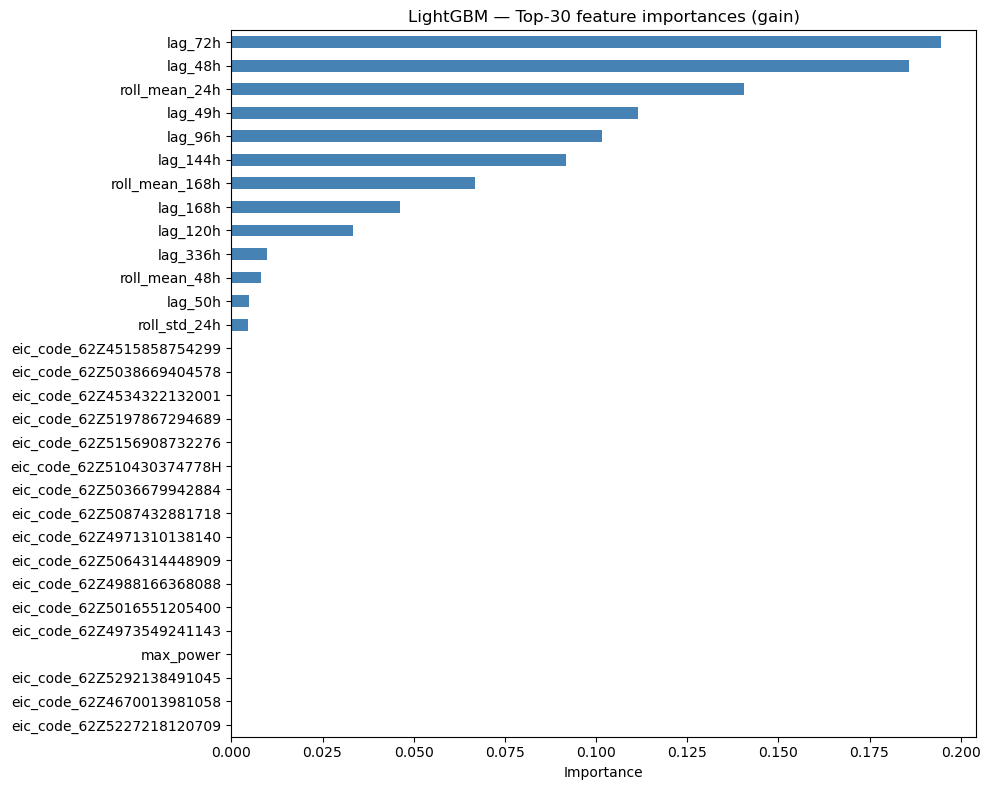

In [14]:
import matplotlib.pyplot as plt

fi = pd.Series(
    final_model.feature_importances_,
    index=train.drop(columns=Y_COL).columns,
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
fi.head(30).sort_values().plot.barh(ax=ax, color="steelblue")
ax.set_title("LightGBM — Top-30 feature importances (gain)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

In [15]:
fi

lag_72h                      0.194600
lag_48h                      0.185779
roll_mean_24h                0.140604
lag_49h                      0.111641
lag_96h                      0.101645
                               ...   
eic_code_62Z0453715929868    0.000000
eic_code_62Z0352290641310    0.000000
eic_code_62Z0285733378448    0.000000
eic_code_62Z0271773349182    0.000000
eic_code_62Z9997819406173    0.000000
Length: 576, dtype: float32

In [ ]:
for col in calendar_cols + cat_columns:
    # if col == Y_COL:
    #     continue
    fi = undo_ohe(fi, col)

## Forecast visualisation

In [16]:
import matplotlib.dates as mdates


def plot_forecast(eval_df, eic_code, start_dt=None, end_dt=None):
    df = eval_df.merge(
        all_data[[GROUP_COL, "time_idx", "datetime"]],
        on=[GROUP_COL, "time_idx"], how="inner",
    )
    df = df[df[GROUP_COL] == eic_code].sort_values("datetime")
    if df.empty:
        raise ValueError(f"No data for EIC code: {eic_code!r}")
    if start_dt is not None:
        df = df[df["datetime"] >= pd.Timestamp(start_dt)]
    if end_dt is not None:
        df = df[df["datetime"] <= pd.Timestamp(end_dt)]
    if df.empty:
        raise ValueError("No data in the specified datetime range.")

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(df["datetime"], df[Y_COL],  label="True",      linewidth=1, color="steelblue")
    ax.plot(df["datetime"], df["pred"], label="Predicted", linewidth=1, color="tomato", alpha=0.85)
    ax.set_title(
        f"{eic_code}  |  MAPE={mape(df[Y_COL], df['pred']):.3f}"
        f"  RMSE={rmse(df[Y_COL], df['pred']):.2f}"
        f"  ({df['datetime'].min().date()} – {df['datetime'].max().date()})"
    )
    ax.set_xlabel("Datetime")
    ax.set_ylabel(Y_COL)
    ax.legend()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
    fig.autofmt_xdate(rotation=0, ha="center")
    plt.tight_layout()
    plt.show()


# Example:
# plot_forecast(val_eval,  eic_code="<code>")
# plot_forecast(test_eval, eic_code="<code>", start_dt="2025-08-25", end_dt="2025-08-26")

In [17]:
plot_forecast(test_eval, eic_code='62Z9042463861989')

KeyError: "['datetime'] not in index"

In [ ]:
plot_forecast(test_eval, eic_code='62Z2410378897684')